# 📊 ACC102 Track 2: AAPL vs MSFT Stock Analysis

This notebook compares the stock performance of Apple Inc. and Microsoft Corporation from 2019 to 2026.

### Objectives:
- Compare return performance
- Analyze risk characteristics
- Evaluate risk-return relationship

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
print("Loading data...")

df_aapl = pd.read_csv("Apple_stock_data.csv")
df_msft = pd.read_csv("Microsoft_stock_data.csv")

df_aapl.head(), df_msft.head()

Loading data...


(         Date     Close      High       Low      Open     Volume
 0  1980-12-12  0.098485  0.098913  0.098485  0.098485  469033600
 1  1980-12-15  0.093347  0.093775  0.093347  0.093775  175884800
 2  1980-12-16  0.086495  0.086924  0.086495  0.086924  105728000
 3  1980-12-17  0.088636  0.089064  0.088636  0.088636   86441600
 4  1980-12-18  0.091206  0.091634  0.091206  0.091206   73449600,
          Date     Close      High       Low      Open    Volume
 0  1986-03-26  0.057666  0.058195  0.055550  0.056079  22752000
 1  1986-03-27  0.058724  0.058724  0.057666  0.057666  16848000
 2  1986-03-31  0.058195  0.058724  0.057137  0.058724  12873600
 3  1986-04-01  0.057666  0.058195  0.057666  0.058195  11088000
 4  1986-04-02  0.058195  0.059253  0.057666  0.057666  27014400)

In [6]:
def get_price_column(df):
    possible_columns = ['Adj Close', 'AdjClose', 'Adjusted Close', 'Close', 'close']
    for col in possible_columns:
        if col in df.columns:
            return col
    raise ValueError("No valid price column found.")

aapl_price_col = get_price_column(df_aapl)
msft_price_col = get_price_column(df_msft)

print(f"AAPL price column: {aapl_price_col}")
print(f"MSFT price column: {msft_price_col}")

AAPL price column: Close
MSFT price column: Close


In [7]:
df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])
df_msft['Date'] = pd.to_datetime(df_msft['Date'])

start_date = '2019-01-01'
end_date = '2026-04-21'

df_aapl_clean = df_aapl[(df_aapl['Date'] >= start_date) & (df_aapl['Date'] <= end_date)].copy()
df_msft_clean = df_msft[(df_msft['Date'] >= start_date) & (df_msft['Date'] <= end_date)].copy()

df_aapl_clean = df_aapl_clean.sort_values('Date').reset_index(drop=True).dropna()
df_msft_clean = df_msft_clean.sort_values('Date').reset_index(drop=True).dropna()

print("Cleaned Data Shapes:")
print("AAPL:", df_aapl_clean.shape)
print("MSFT:", df_msft_clean.shape)

Cleaned Data Shapes:
AAPL: (1681, 6)
MSFT: (1834, 6)


In [8]:
# Daily Return
df_aapl_clean['Daily_Return'] = df_aapl_clean[aapl_price_col].pct_change()
df_msft_clean['Daily_Return'] = df_msft_clean[msft_price_col].pct_change()

# Cumulative Return
df_aapl_clean['Cumulative_Return'] = (1 + df_aapl_clean['Daily_Return'].fillna(0)).cumprod()
df_msft_clean['Cumulative_Return'] = (1 + df_msft_clean['Daily_Return'].fillna(0)).cumprod()

df_aapl_clean[['Date', 'Cumulative_Return']].head()

,Date,Cumulative_Return
0,2019-01-02,1.000000
1,2019-01-03,0.900393
2,2019-01-04,0.938830
3,2019-01-07,0.936740
4,2019-01-08,0.954597


In [9]:
# Volatility
aapl_vol = df_aapl_clean['Daily_Return'].std() * np.sqrt(252)
msft_vol = df_msft_clean['Daily_Return'].std() * np.sqrt(252)

# Total Return
aapl_total_return = df_aapl_clean['Cumulative_Return'].iloc[-1] - 1
msft_total_return = df_msft_clean['Cumulative_Return'].iloc[-1] - 1

# Max Drawdown
def calculate_max_drawdown(series):
    peak = series.cummax()
    drawdown = (series - peak) / peak
    return drawdown.min()

aapl_mdd = calculate_max_drawdown(df_aapl_clean['Cumulative_Return'])
msft_mdd = calculate_max_drawdown(df_msft_clean['Cumulative_Return'])

# Display nicely
results = pd.DataFrame({
    "Metric": ["Total Return", "Volatility", "Max Drawdown"],
    "AAPL": [aapl_total_return, aapl_vol, aapl_mdd],
    "MSFT": [msft_total_return, msft_vol, msft_mdd]
})

results

,Metric,AAPL,MSFT
0,Total Return,5.236824,3.428840
1,Volatility,0.315038,0.285721
2,Max Drawdown,-0.333605,-0.371485


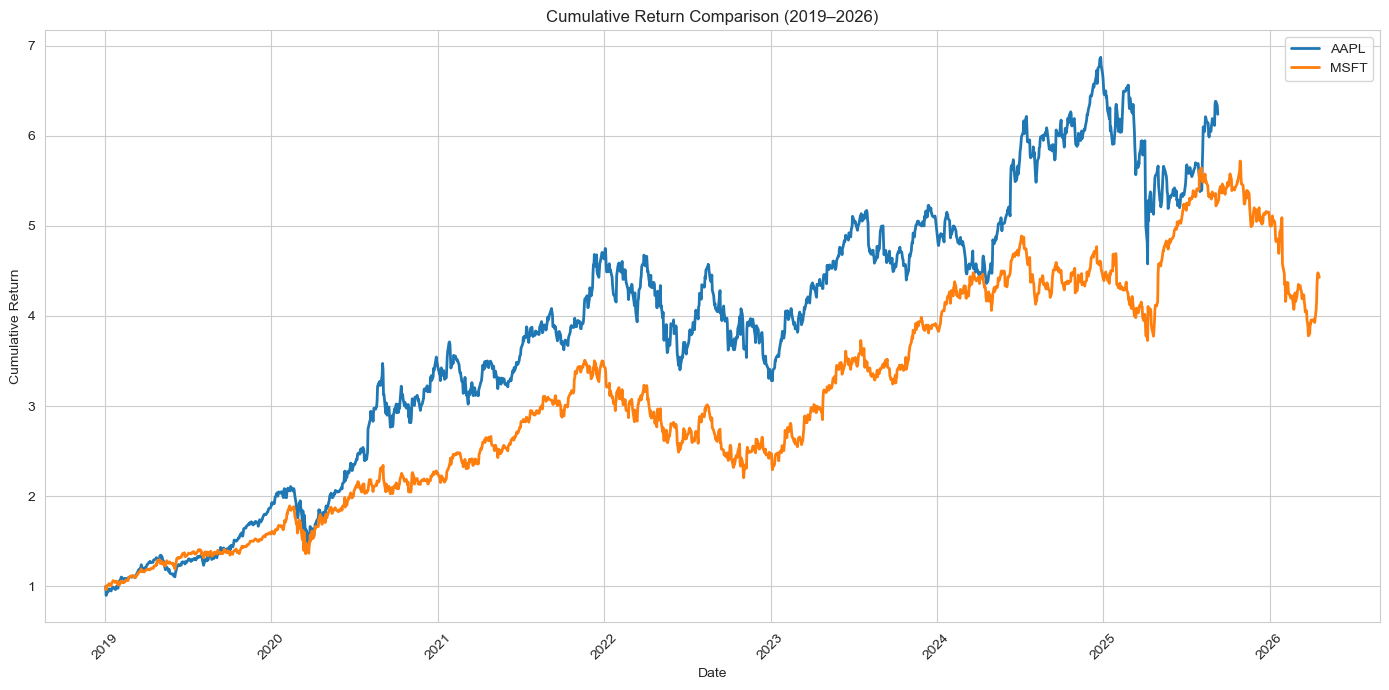

In [10]:
plt.figure(figsize=(14,7))
plt.plot(df_aapl_clean['Date'], df_aapl_clean['Cumulative_Return'], label='AAPL', linewidth=2)
plt.plot(df_msft_clean['Date'], df_msft_clean['Cumulative_Return'], label='MSFT', linewidth=2)

plt.title('Cumulative Return Comparison (2019–2026)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

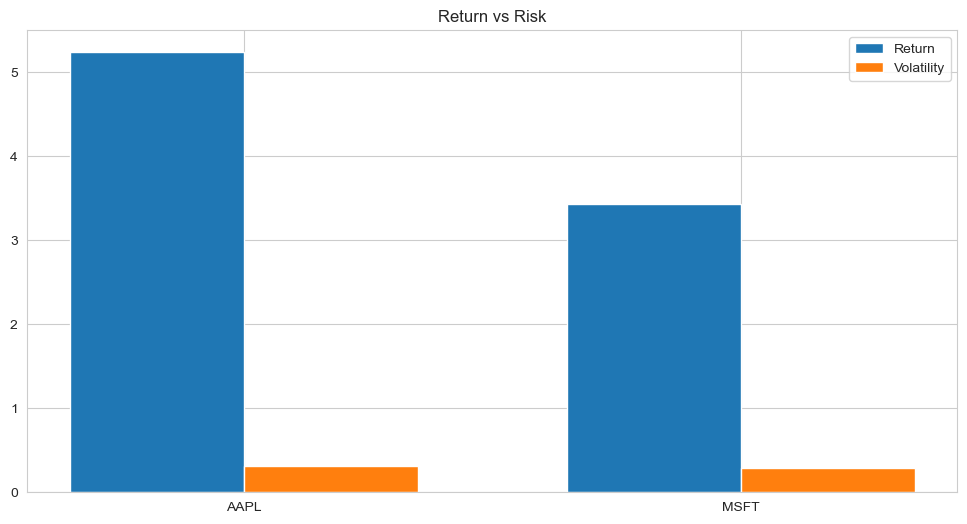

In [11]:
companies = ['AAPL', 'MSFT']
returns = [aapl_total_return, msft_total_return]
vols = [aapl_vol, msft_vol]

x = np.arange(len(companies))
width = 0.35

plt.bar(x - width/2, returns, width, label='Return')
plt.bar(x + width/2, vols, width, label='Volatility')

plt.xticks(x, companies)
plt.title('Return vs Risk')
plt.legend()
plt.show()

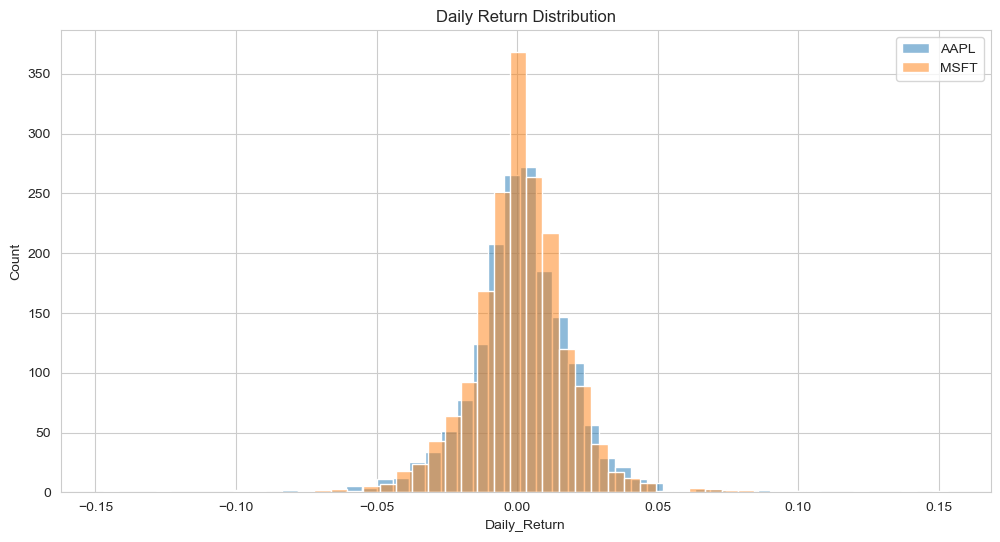

In [12]:
sns.histplot(df_aapl_clean['Daily_Return'].dropna(), bins=50, alpha=0.5, label='AAPL')
sns.histplot(df_msft_clean['Daily_Return'].dropna(), bins=50, alpha=0.5, label='MSFT')

plt.title('Daily Return Distribution')
plt.legend()
plt.show()

In [13]:
df_aapl_clean.to_csv("AAPL_cleaned.csv", index=False)
df_msft_clean.to_csv("MSFT_cleaned.csv", index=False)

print("Files exported successfully.")

Files exported successfully.


## 📌 Conclusion

- Apple delivers higher total return
- Microsoft shows more stable volatility
- Both stocks exhibit similar downside risk
- Risk-return tradeoff differs between the two companies

👉 Microsoft may be more suitable for risk-averse investors  
👉 Apple may be more attractive for growth-oriented investors